# Modelos de Deep Learning: Aplicaciones prácticas

# **Tarea 1**



---
# PROBLEMA 1
## Clasificador lineal en TensorFlow

**Modificaciones solicitadas:**
1. Cambiar color del conjunto superior a verde y del inferior a rojo
2. Cambiar matriz de covarianza para que las nubes sean casi esféricas
3. Dibujar línea de decisión negra discontinua en lugar de roja

**Generando dos clases de puntos aleatorios en un plano 2D**

In [ ]:
import tensorflow as tf # Importación de la librería TensorFlow
from tensorflow import keras
import numpy as np # Importación de NumPy para operaciones numéricas
import matplotlib.pyplot as plt # Importación de Matplotlib para visualización

np.random.seed(42) # Semilla de NumPy para reproducibilidad
tf.random.set_seed(42) # Semilla de TensorFlow para reproducibilidad

num_samples_per_class = 1000 # Cantidad de muestras para cada clase
# Matriz de covarianza definida para generar nubes casi esféricas
cov_esferica = [[0.2, 0.01], [0.01, 0.2]]
# Generación de muestras negativas con distribución normal multivariada
negative_samples = np.random.multivariate_normal(
    mean=[0, 3], cov=cov_esferica, size=num_samples_per_class)
# Generación de muestras positivas con distribución normal multivariada
positive_samples = np.random.multivariate_normal(
    mean=[3, 0], cov=cov_esferica, size=num_samples_per_class)

**Apilando las dos clases en un array con forma (2000, 2)**

In [ ]:
# Combinación de ambas clases en una sola matriz de entrada [cite: 4, 5]
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

In [ ]:
inputs.shape # Verificación de las dimensiones de la matriz de entrada (2000, 2)

(2000, 2)

**Generando los targets correspondientes (0 y 1)**

In [ ]:
# Generación de etiquetas: 0 para muestras negativas y 1 para positivas [cite: 4]
targets = np.vstack((np.zeros((num_samples_per_class, 1), dtype="float32"),
                     np.ones((num_samples_per_class, 1), dtype="float32")))

**Graficando las dos clases de puntos - Conjunto inferior (0) en ROJO, superior (1) en VERDE**

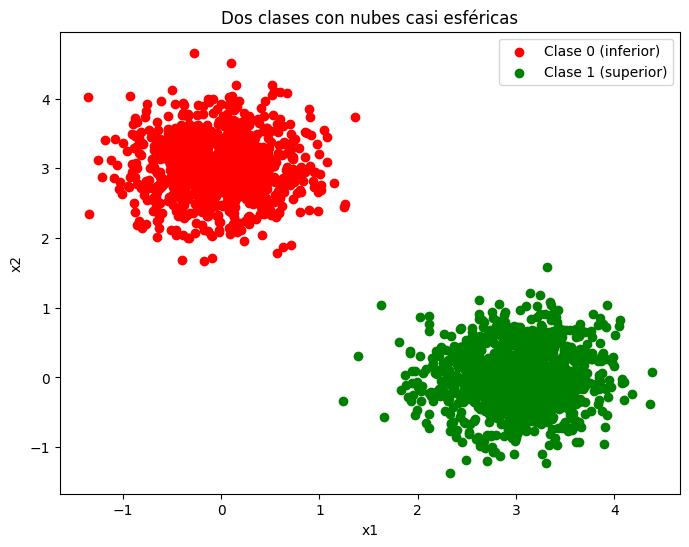

In [ ]:
plt.figure(figsize=(8, 6)) # Configuración del tamaño de la figura para la gráfica
mask0 = (targets[:, 0] == 0).flatten() # Máscara para seleccionar los puntos de la Clase 0
mask1 = (targets[:, 0] == 1).flatten() # Máscara para seleccionar los puntos de la Clase 1
plt.scatter(inputs[mask0, 0], inputs[mask0, 1], c='red', label='Clase 0 (inferior)') # Graficación de Clase 0 en rojo
plt.scatter(inputs[mask1, 0], inputs[mask1, 1], c='green', label='Clase 1 (superior)') # Graficación de Clase 1 en verde
plt.legend() # Inclusión de la leyenda en la gráfica
plt.xlabel('x1') # Etiqueta del eje horizontal
plt.ylabel('x2') # Etiqueta del eje vertical
plt.title('Dos clases con nubes casi esféricas') # Título descriptivo de la gráfica
plt.show() # Despliegue de la visualización

**Creando las variables del clasificador lineal**

In [ ]:
input_dim = 2 # Definición de la dimensión de entrada (x1, x2)
output_dim = 1 # Definición de la dimensión de salida (predicción escalar)
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim))) # Inicialización aleatoria de los pesos
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,))) # Inicialización en cero del sesgo (bias)

**Función de forward pass**

In [ ]:
def model(inputs):
    return tf.matmul(inputs, W) + b # Cálculo del paso hacia adelante (W * x + b)

**Función de pérdida (error cuadrático medio)**

In [ ]:
def square_loss(targets, predictions):
    per_sample_losses = tf.square(targets - predictions) # Cálculo del error al cuadrado por muestra
    return tf.reduce_mean(per_sample_losses) # Promedio de los errores para obtener la pérdida total

**Función de paso de entrenamiento**

In [ ]:
learning_rate = 0.1 # Definición de la tasa de aprendizaje para el descenso por gradiente

def training_step(inputs, targets): # Función que ejecuta un único paso de optimización
    with tf.GradientTape() as tape: # Registro de operaciones para el cálculo automático de gradientes
        predictions = model(inputs) # Generación de predicciones con el estado actual del modelo
        loss = square_loss(targets, predictions) # Cálculo de la pérdida para el lote actual
    # Obtención de los gradientes de la pérdida respecto a W y b
    grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W, b])
    W.assign_sub(grad_loss_wrt_W * learning_rate) # Actualización del peso restando el gradiente escalado
    b.assign_sub(grad_loss_wrt_b * learning_rate) # Actualización del sesgo restando el gradiente escalado
    return loss # Retorno del valor de la pérdida para monitoreo

**Ciclo de entrenamiento por lotes**

In [ ]:
for step in range(40): # Ciclo de entrenamiento principal limitado a 40 iteraciones
    loss = training_step(inputs, targets) # Ejecución del entrenamiento sobre el conjunto de datos completo
    if step % 10 == 0: # Condición para imprimir el progreso cada 10 pasos
        print(f"Loss at step {step}: {loss:.4f}") # Visualización del valor de la pérdida en consola

Loss at step 0: 1.4824
Loss at step 10: 0.0296
Loss at step 20: 0.0270
Loss at step 30: 0.0247


**Graficando predicciones con LÍNEA DE DECISIÓN NEGRA DISCONTINUA**

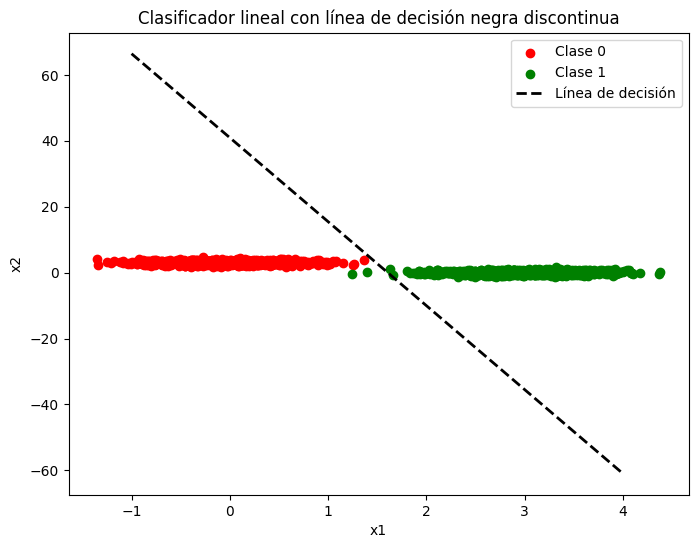

In [ ]:
predictions = model(inputs) # Generación de predicciones finales tras el entrenamiento
w = W.numpy() # Conversión de los pesos de TensorFlow a formato NumPy
b_val = b.numpy() # Conversión del sesgo de TensorFlow a formato NumPy
x = np.linspace(-1, 4, 100) # Creación de un rango de valores para el eje x
# Cálculo de la línea de decisión despejando x2 de la ecuación del modelo [cite: 6]
y = -(w[0, 0] / w[1, 0]) * x + (0.5 - b_val[0]) / w[1, 0]

plt.figure(figsize=(8, 6)) # Definición del tamaño de la figura final
mask0 = (targets[:, 0] == 0).flatten() # Selección de índices para la Clase 0
mask1 = (targets[:, 0] == 1).flatten() # Selección de índices para la Clase 1
plt.scatter(inputs[mask0, 0], inputs[mask0, 1], c='red', label='Clase 0') # Puntos de Clase 0 en rojo
plt.scatter(inputs[mask1, 0], inputs[mask1, 1], c='green', label='Clase 1') # Puntos de Clase 1 en verde
# Dibujo de la línea de decisión negra discontinua requerida por la tarea [cite: 6]
plt.plot(x, y, 'k--', linewidth=2, label='Línea de decisión')
plt.legend() # Activación de las leyendas de la gráfica
plt.xlabel('x1') # Etiqueta del eje x
plt.ylabel('x2') # Etiqueta del eje y
plt.title('Clasificador lineal con línea de decisión negra discontinua') # Título de la visualización final
plt.show() # Visualización de la gráfica completa con datos y frontera de decisión

---
# PROBLEMA 2
## Regresión lineal con tf.GradientTape()

Crear conjunto sintético de 100 puntos:
- x: rango [0, 8], distribución uniforme
- y: línea recta + ruido gaussiano (std=0.2)
- Resolver con descenso por gradiente usando tf.GradientTape()

In [ ]:
np.random.seed(42) # Semilla de NumPy para asegurar la reproducibilidad de los datos
tf.random.set_seed(42) # Semilla de TensorFlow para asegurar la reproducibilidad de los pesos

n_points = 100 # Definición de 100 puntos de datos sintéticos
# Generación de x en rango [0, 10] con distribución uniforme [cite: 10, 11]
x_data = np.random.uniform(0, 10, size=(n_points, 1)).astype(np.float32)

pendiente_real = 2.0 # Definición de la pendiente para la línea recta base [cite: 11]
intercepto_real = 1.0 # Definición del intercepto para la línea recta base [cite: 11]
# Generación de y con ruido gaussiano de desviación estándar 0.4
y_data = (pendiente_real * x_data + intercepto_real +
          np.random.normal(0, 0.4, size=(n_points, 1))).astype(np.float32)

In [ ]:
# Inicialización de la pendiente (w) con valores aleatorios uniformes
w_reg = tf.Variable(tf.random.uniform(shape=(1, 1)))
# Inicialización del intercepto (b) en cero como variable entrenable
b_reg = tf.Variable(tf.zeros(shape=(1,)))

def regression_model(x):
    return tf.matmul(x, w_reg) + b_reg # Función del modelo lineal: y = x*w + b

def mse_loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred)) # Cálculo del error cuadrático medio (MSE)

learning_rate_reg = 0.01 # Tasa de aprendizaje para ajustar los parámetros de regresión
epochs = 500 # Número de iteraciones para el ciclo de entrenamiento

In [ ]:
for epoch in range(epochs): # Inicio del ciclo de entrenamiento para ajustar parámetros mediante descenso por gradiente [cite: 14]
    with tf.GradientTape() as tape: # Uso de GradientTape para el cálculo automático de los gradientes [cite: 15]
        y_pred = regression_model(x_data) # Ejecución del modelo para obtener las predicciones actuales
        loss = mse_loss(y_data, y_pred) # Cálculo del error cuadrático medio respecto a los puntos sintéticos [cite: 13]
    gradients = tape.gradient(loss, [w_reg, b_reg]) # Cálculo de las derivadas de la pérdida respecto a los parámetros
    w_reg.assign_sub(gradients[0] * learning_rate_reg) # Ajuste de la pendiente restando el gradiente escalado [cite: 14]
    b_reg.assign_sub(gradients[1] * learning_rate_reg) # Ajuste del intercepto restando el gradiente escalado [cite: 14]
    if (epoch + 1) % 100 == 0: # Condición para monitorear el progreso del entrenamiento
        print(f"Epoch {epoch+1}, Loss: {loss.numpy():.6f}") # Impresión de la pérdida para verificar la convergencia

Epoch 100, Loss: 0.199376
Epoch 200, Loss: 0.152172
Epoch 300, Loss: 0.136654
Epoch 400, Loss: 0.131552
Epoch 500, Loss: 0.129875


In [ ]:
print(f"\nParámetros encontrados:") # Sección para mostrar los resultados finales del análisis [cite: 28]
print(f"  Pendiente: {w_reg.numpy()[0,0]:.4f} (real: {pendiente_real})") # Muestra del valor final de la pendiente
print(f"  Intercepto: {b_reg.numpy()[0]:.4f} (real: {intercepto_real})") # Muestra del valor final del intercepto


Parámetros encontrados:
  Pendiente: 1.9898 (real: 2.0)
  Intercepto: 1.0325 (real: 1.0)


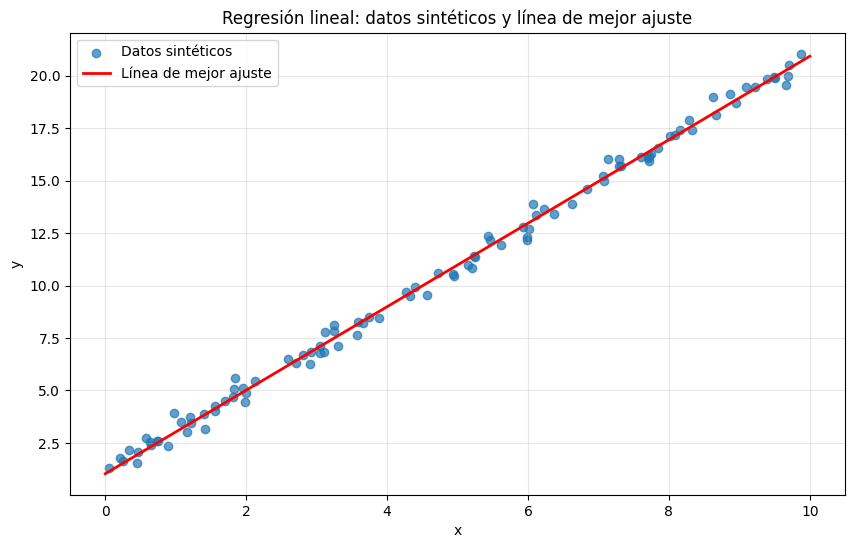

In [ ]:
# Creación de un rango de 100 puntos entre 0 y 10 para graficar la línea
x_plot = np.linspace(0, 10, 100).reshape(-1, 1).astype(np.float32)
# Generación de las predicciones del modelo para los puntos del rango creado
y_plot = regression_model(x_plot).numpy()

plt.figure(figsize=(10, 6)) # Definición del tamaño de la figura para la visualización de la regresión
plt.scatter(x_data, y_data, alpha=0.7, label='Datos sintéticos') # Graficación de los puntos con ruido
plt.plot(x_plot, y_plot, 'r-', linewidth=2, label='Línea de mejor ajuste') # Dibujo de la línea de regresión en rojo
plt.xlabel('x') # Etiqueta para el eje de la variable independiente
plt.ylabel('y') # Etiqueta para el eje de la variable dependiente
plt.title('Regresión lineal: datos sintéticos y línea de mejor ajuste') # Título de la gráfica de regresión
plt.legend() # Inclusión de la leyenda para identificar los elementos de la gráfica
plt.grid(True, alpha=0.3) # Activación de una cuadrícula tenue para facilitar la lectura
plt.show() # Despliegue de la gráfica final del Problema 2

---
# PROBLEMA 3
## Red neuronal para clasificación binaria (Iris)

Revisión del cuaderno DL_Tarea_1_PartII - Implementación desde cero con NumPy

In [ ]:
%matplotlib inline
# Configuración para mostrar gráficos de Matplotlib dentro del cuaderno
import numpy as np # Importación de NumPy para el manejo de arreglos y operaciones matemáticas
import matplotlib.pyplot as plt # Importación de Matplotlib para la visualización de datos
from sklearn import datasets # Importación de datasets de Scikit-Learn para cargar el conjunto Iris

np.random.seed(42) # Definición de semilla para garantizar resultados reproducibles en NumPy

In [ ]:
import tensorflow as tf # Importación de la librería TensorFlow
print(f"TensorFlow: {tf.__version__}") # Verificación de la versión instalada de TensorFlow
print(f"Keras: {tf.keras.__version__}") # Verificación de la versión instalada de Keras

TensorFlow: 2.19.0
Keras: 3.13.2


In [ ]:
iris = datasets.load_iris() # Carga del conjunto de datos Iris desde Scikit-Learn
X = iris.data[:, :2] # Selección de las primeras dos características
y = (iris.target != 0) * 1 # Conversión del problema a clasificación binaria

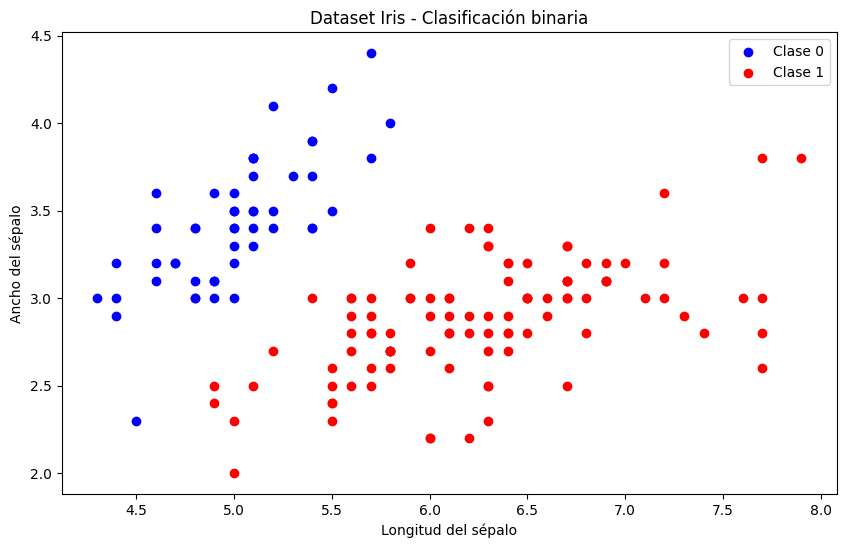

In [ ]:
plt.figure(figsize=(10, 6)) # Configuración del tamaño de la figura para la visualización del dataset
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='b', label='Clase 0') # Graficación de puntos de la Clase 0 en azul
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='r', label='Clase 1') # Graficación de puntos de la Clase 1 en rojo
plt.legend() # Inclusión de la leyenda descriptiva de las clases
plt.xlabel('Longitud del sépalo') # Etiqueta para el eje x representando la longitud del sépalo
plt.ylabel('Ancho del sépalo') # Etiqueta para el eje y representando el ancho del sépalo
plt.title('Dataset Iris - Clasificación binaria') # Título de la gráfica de dispersión
plt.show() # Despliegue de la visualización inicial de los datos

In [ ]:
X = X.T # Transposición de la matriz de características para el procesamiento neuronal [cite: 21]
y = y.reshape(1, 150) # Ajuste de las dimensiones del vector de etiquetas a (1, 150) [cite: 21]
print(f"X shape: {X.shape}") # Verificación de las nuevas dimensiones de la matriz X
print(f"y shape: {y.shape}") # Verificación de las nuevas dimensiones del vector y

X shape: (2, 150)
y shape: (1, 150)


**Implementación de funciones: sigmoid, forward/backward propagation, y entrenamiento**

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x)) # Función de activación para convertir valores en probabilidades

def layer_sizes(X, Y):
    n_x = X.shape[0] # Tamaño de la capa de entrada (2 características)
    n_h = 4 # Definición de 4 neuronas para la capa oculta
    n_y = Y.shape[0] # Tamaño de la capa de salida (1 neurona para clasificación binaria)
    return (n_x, n_h, n_y)

def initialize_parameters(n_x, n_h, n_y):
    np.random.seed(2) # Semilla fija para inicialización reproducible
    W1 = 0.01 * np.random.randn(n_h, n_x) # Pesos de la capa oculta inicializados aleatoriamente
    b1 = np.zeros((n_h, 1)) # Sesgos de la capa oculta inicializados en cero
    W2 = 0.01 * np.random.randn(n_y, n_h) # Pesos de la capa de salida inicializados aleatoriamente
    b2 = np.zeros((n_y, 1)) # Sesgos de la capa de salida inicializados en cero
    return {'W1': W1, 'b1': b1, 'W2': W2, 'b2': b2}

def forward_propagation(X, parameters):
    W1, b1 = parameters['W1'], parameters['b1'] # Extracción de parámetros de la primera capa
    W2, b2 = parameters['W2'], parameters['b2'] # Extracción de parámetros de la segunda capa
    Z1 = np.dot(W1, X) + b1 # Combinación lineal de la primera capa
    A1 = np.tanh(Z1) # Activación tangente hiperbólica para la capa oculta
    Z2 = np.dot(W2, A1) + b2 # Combinación lineal de la segunda capa
    A2 = sigmoid(Z2) # Activación sigmoide para obtener la salida final
    cache = {'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2} # Almacenamiento de valores para el backpropagation
    return A2, cache

def compute_cost(A2, Y, parameters):
    m = Y.shape[1] # Número total de ejemplos de entrenamiento
    A2 = np.clip(A2, 1e-8, 1 - 1e-8) # Evita errores de logaritmo con valores extremos de 0 o 1
    logprobs = np.multiply(np.log(A2), Y) + np.multiply(np.log(1 - A2), 1 - Y) # Cálculo de la entropía cruzada
    return -np.sum(logprobs) / m # Promedio del costo total sobre todos los ejemplos

def backward_propagation(parameters, cache, X, Y):
    m = X.shape[1] # Número de ejemplos para normalizar gradientes
    W2 = parameters['W2'] # Uso de pesos de salida para calcular error en capa oculta
    A1, A2 = cache['A1'], cache['A2'] # Recuperación de activaciones del forward pass
    dZ2 = A2 - Y # Error en la capa de salida
    dW2 = (1/m) * np.dot(dZ2, A1.T) # Gradiente de los pesos de la capa de salida
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True) # Gradiente de los sesgos de la capa de salida
    dZ1 = np.dot(W2.T, dZ2) * (1 - np.power(A1, 2)) # Error propagado a la capa oculta (derivada de tanh)
    dW1 = (1/m) * np.dot(dZ1, X.T) # Gradiente de los pesos de la capa oculta
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True) # Gradiente de los sesgos de la capa oculta
    return {'dW1': dW1, 'db1': db1, 'dW2': dW2, 'db2': db2}

def update_parameters(parameters, grads, learning_rate=1.2):
    parameters['W1'] -= learning_rate * grads['dW1'] # Actualización de pesos W1 según el gradiente
    parameters['b1'] -= learning_rate * grads['db1'] # Actualización de sesgos b1 según el gradiente
    parameters['W2'] -= learning_rate * grads['dW2'] # Actualización de pesos W2 según el gradiente
    parameters['b2'] -= learning_rate * grads['db2'] # Actualización de sesgos b2 según el gradiente
    return parameters

In [ ]:
def nn_model(X, Y, n_h, lr=1.2, num_iterations=10000, print_cost=False):
    np.random.seed(3) # Semilla para asegurar que los resultados del modelo sean reproducibles
    n_x, _, n_y = layer_sizes(X, Y) # Obtención de las dimensiones de las capas según los datos [cite: 20]
    parameters = initialize_parameters(n_x, n_h, n_y) # Inicialización de pesos y sesgos [cite: 20]
    for i in range(num_iterations): # Ciclo de optimización iterativo para entrenar la red [cite: 20]
        A2, cache = forward_propagation(X, parameters) # Paso hacia adelante para obtener la predicción actual [cite: 20]
        cost = compute_cost(A2, Y, parameters) # Cálculo del error entre la predicción y el valor real [cite: 20]
        grads = backward_propagation(parameters, cache, X, Y) # Paso hacia atrás para calcular los gradientes [cite: 20]
        parameters = update_parameters(parameters, grads, learning_rate=lr) # Actualización de parámetros [cite: 20]
        if print_cost and i % 1000 == 0: # Condición para imprimir el costo cada 1000 iteraciones [cite: 28, 29]
            print(f"Cost after iteration {i}: {cost:.4f}") # Visualización del progreso del costo [cite: 28]
    return parameters # Retorno de los parámetros entrenados del modelo

In [ ]:
# Entrenamiento final del modelo con 10,000 iteraciones y tasa de aprendizaje de 0.3
parameters = nn_model(X, y, n_h=4, lr=0.3, num_iterations=10000, print_cost=True)

Cost after iteration 0: 0.6930
Cost after iteration 1000: 0.0259
Cost after iteration 2000: 0.0156
Cost after iteration 3000: 0.0090
Cost after iteration 4000: 0.0059
Cost after iteration 5000: 0.0044
Cost after iteration 6000: 0.0034
Cost after iteration 7000: 0.0028
Cost after iteration 8000: 0.0023
Cost after iteration 9000: 0.0020


In [ ]:
def predict(parameters, X):
    A2, _ = forward_propagation(X, parameters) # Obtención de la probabilidad de salida [cite: 20]
    return (A2 > 0.5) # Clasificación binaria basada en el umbral de 0.5 [cite: 20]

predictions = predict(parameters, X) # Generación de predicciones para el conjunto de entrenamiento
# Cálculo del porcentaje de aciertos comparando predicciones con etiquetas reales [cite: 28, 29]
accuracy = np.mean((predictions == y).astype(float)) * 100
print(f"Precisión en entrenamiento: {accuracy:.2f}%") # Visualización del resultado final de precisión [cite: 22, 28]

Precisión en entrenamiento: 100.00%
